<a href="https://colab.research.google.com/github/MerveSevim44/deep_learning_workss/blob/main/assignment_istanbul_weather_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Istanbul Weather Forecasting

# Imports

In [5]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 4.8 MB/s eta 0:00:00


In [6]:
import random, datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from keras_tuner import HyperModel, HyperParameters
from keras_tuner.tuners import RandomSearch

random.seed(46)
np.random.seed(46)
tf.random.set_seed(46)

# Functions

In [7]:
def load_and_preprocess(data_path):
    data = pd.read_csv(data_path)
    data['temp_celsius'] = data['temp'] - 273.15
    # data['date'] = pd.to_datetime(data['dt_iso']).dt.date
    data['date'] = pd.to_datetime(data['dt_iso'], format='%Y-%m-%d %H:%M:%S +0000 UTC').dt.date
    data = data.drop(columns=['dt_iso', 'temp'])
    data['date'] = pd.to_datetime(data['date'])
    data.set_index('date', inplace=True)
    return data.resample('D').mean()

def split_data_by_time(df, train_frac=0.7, val_frac=0.15):
    n = len(df)
    train_size = int(n * train_frac)
    val_size = int(n * val_frac)
    test_size = n - train_size - val_size
    train_df = df[:train_size]
    val_df = df[train_size:train_size+val_size]
    test_df = df[train_size+val_size:]
    return train_df, val_df, test_df


def scale_data(train_df, val_df, test_df, feature_columns, target_column):
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()
    scaler_x.fit(train_df[feature_columns])
    scaler_y.fit(train_df[[target_column]])
    train_x = scaler_x.transform(train_df[feature_columns])
    val_x = scaler_x.transform(val_df[feature_columns])
    test_x = scaler_x.transform(test_df[feature_columns])
    train_y = scaler_y.transform(train_df[[target_column]])
    val_y = scaler_y.transform(val_df[[target_column]])
    test_y = scaler_y.transform(test_df[[target_column]])
    return train_x, val_x, test_x, train_y.flatten(), val_y.flatten(), test_y.flatten(), scaler_x, scaler_y

def create_timewindow(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:(i + time_steps)]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys), time_steps

def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()


def evaluate_predictions(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y):

    y_train_pred_ = model.predict(X_train, verbose=0)
    y_val_pred = model.predict(X_val, verbose=0)
    y_test_pred = model.predict(X_test, verbose=0)

    true_y_train_pred = scaler_y.inverse_transform(y_train_pred_)
    true_y_val_pred = scaler_y.inverse_transform(y_val_pred)
    true_y_test_pred = scaler_y.inverse_transform(y_test_pred)

    true_y_train = scaler_y.inverse_transform(y_train.reshape(-1, 1))
    true_y_val = scaler_y.inverse_transform(y_val.reshape(-1, 1))
    true_y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

    train_mse = mean_squared_error(true_y_train, true_y_train_pred)
    val_mse = mean_squared_error(true_y_val, true_y_val_pred)
    test_mse = mean_squared_error(true_y_test, true_y_test_pred)
    print("Train MSE:", train_mse, "Validation MSE:", val_mse, "Test MSE:", test_mse)
    return true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse


def plot_predictions_with_metrics(train_df, val_df, test_df, true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse, time_steps):
    plt.figure(dpi=200)
    plt.figure(figsize=(30, 10))
    # Train
    train_time = train_df.index[time_steps:]
    plt.plot(train_time, true_y_train, label='True Values (Train)', color='blue')
    plt.plot(train_time, true_y_train_pred, '--', label='Predicted Values (Train)', color='red')

    # Validation
    val_time = val_df.index[time_steps:]
    plt.plot(val_time, true_y_val, label='True Values (Validation)', color='green')
    plt.plot(val_time, true_y_val_pred, '--', label='Predicted Values (Validation)', color='orange')

    # Test
    test_time = test_df.index[time_steps:]
    plt.plot(test_time, true_y_test, label='True Values (Test)', color='purple')
    plt.plot(test_time, true_y_test_pred, '--', label='Predicted Values (Test)', color='pink')

    # Metrics
    plt.text(train_time.min(), true_y_train.max()*1.03, f"Train MSE: {train_mse:.4f}", fontsize=12)
    plt.text(train_time.min(), true_y_train.max()*0.98, f"Validation MSE: {val_mse:.4f}", fontsize=12)
    plt.text(train_time.min(), true_y_train.max()*0.93, f"Test MSE: {test_mse:.4f}", fontsize=12)

    plt.title('Actual and Predicted Values for All Data Sets')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_individual_series(data, figsize=(12, 4)):
    for column in data.columns:
        plt.figure(figsize=figsize)
        plt.plot(data.index, data[column], label=column, color='b')
        plt.title(f'Time Series Visualisation - {column}')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
        plt.show()

# Data Set

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
data_path = "/content/five_years_ist_weather.csv"

# Data Preparation

# Task 1: Veri ön işleme basamaklarını gerçekleştiriniz.

- Veriyi okuma ve ön işleme

- Feature'ları ve target'i seçme

- Veri setini zamana göre train, validasyon ve test seti olarak ayırmak

- Scale etme

- Time window'ları oluşturma

# Task 1 Solution

In [9]:
df = load_and_preprocess(data_path)

print(df.head())




             humidity  wind_speed  clouds_all     pressure   dew_point  \
date                                                                     
2019-01-01  64.916667    5.473750   44.166667  1020.750000  273.427083   
2019-01-02  77.192308    3.921923   82.884615  1012.000000  275.625769   
2019-01-03  80.500000    5.600417   82.500000  1009.416667  275.659167   
2019-01-04  76.375000    7.986667   75.833333  1018.291667  272.872083   
2019-01-05  83.958333    6.635000   72.083333  1014.250000  274.025417   

            temp_celsius  
date                      
2019-01-01      6.390833  
2019-01-02      6.205000  
2019-01-03      5.622917  
2019-01-04      3.455833  
2019-01-05      3.334167  


In [10]:
feature_columns = [col for col in df.columns if col != 'temp_celsius']

target_column = 'temp_celsius'

In [11]:
train_df,val_df, test_df = split_data_by_time(df,train_frac=0.7, val_frac=0.20)
print("Train Sizes:", train_df.shape, "Validation Sizes:", val_df.shape, "Test Sizes:", test_df.shape)

Train Sizes: (1278, 6) Validation Sizes: (365, 6) Test Sizes: (183, 6)


In [12]:
train_scaled_x, val_scaled_x, test_scaled_x, train_scaled_y, val_scaled_y, test_scaled_y, scaler_x, scaler_y = scale_data(train_df,val_df, test_df,feature_columns,target_column)

In [13]:
X_train, y_train, time_steps = create_timewindow(train_scaled_x, train_scaled_y, time_steps = 5)
X_val, y_val, time_steps = create_timewindow(val_scaled_x, val_scaled_y, time_steps = 5)
X_test, y_test, time_steps = create_timewindow(test_scaled_x, test_scaled_y, time_steps = 5)

# Task 2: Veri setini analiz ediniz.

- Değişkenlerin betimsel istatistikleri

- İstanbul'un hava sıcaklığı ortalaması standart sapması nasıl?

- Değişkenleri ayrı ayrı görselleştiriniz.

- Not: Anomaly ve correlation incelemeye gerek yok.

# Task 2 Solution

In [15]:
def plot_individual_series(data, figsize=(12, 4)):
    for column in data.columns:
        plt.figure(figsize=figsize)
        plt.plot(data.index, data[column], label=column, color='b')
        plt.title(f'Time Series Visualisation - {column}')
        plt.xlabel('Date')
        plt.ylabel('Value')
        plt.grid(True)
        plt.legend()
        plt.show()

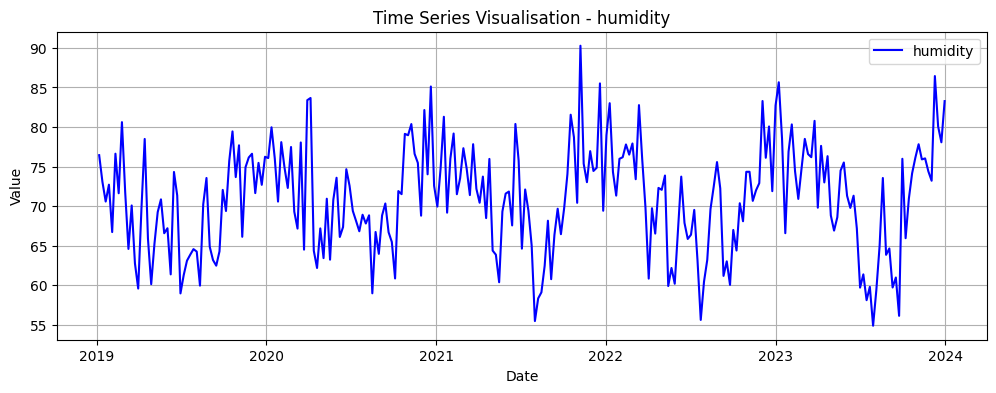

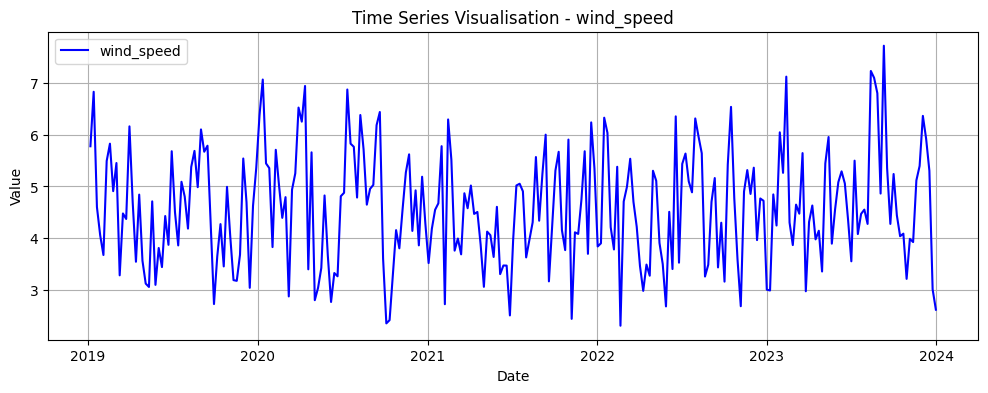

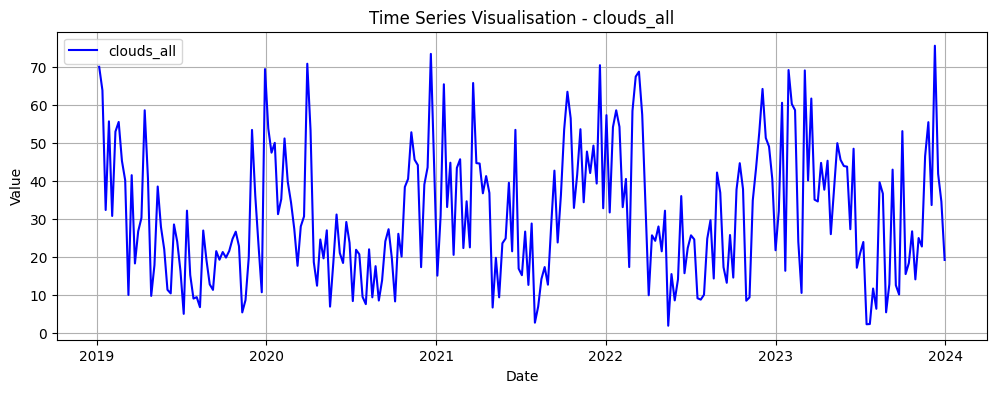

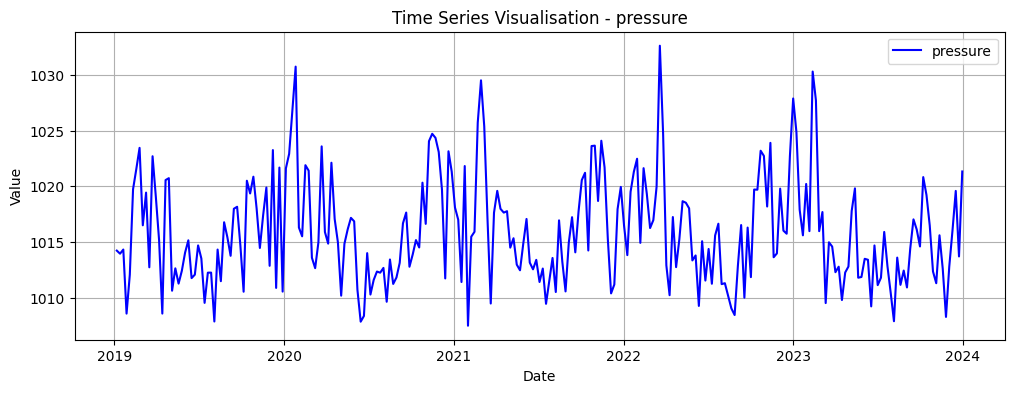

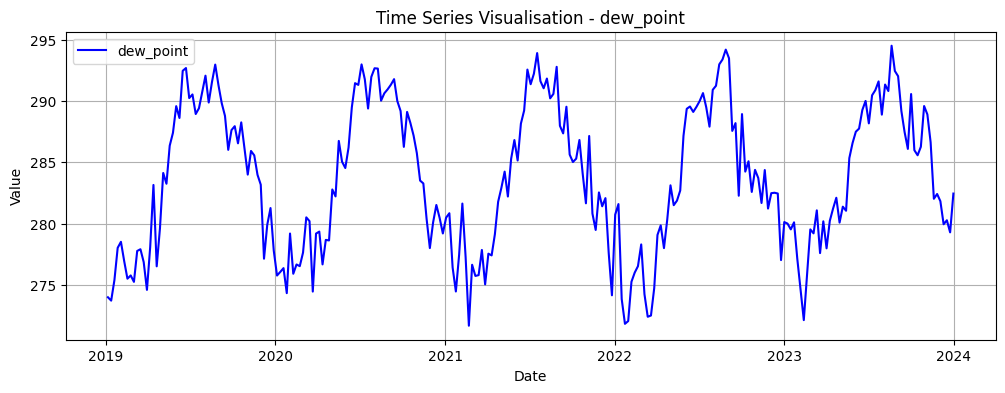

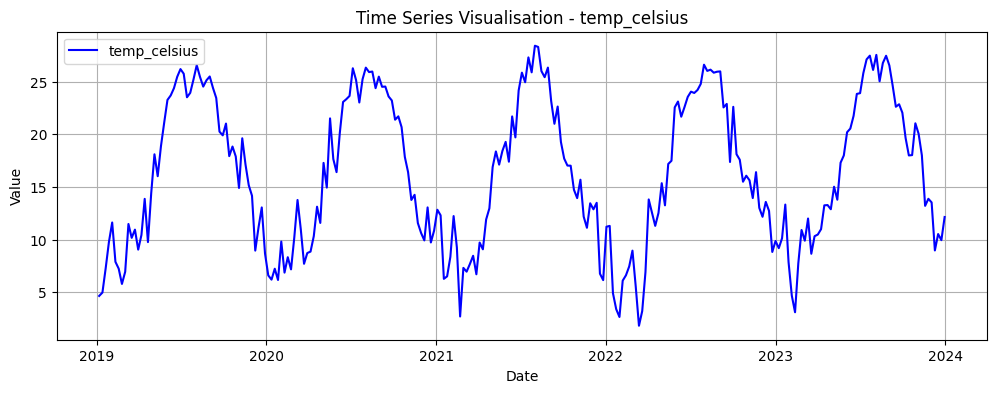

In [21]:
monthly_data = df.resample('W').mean()

plot_individual_series(monthly_data)

In [14]:
df.describe()

,humidity,wind_speed,clouds_all,pressure,dew_point,temp_celsius
count,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000,1826.000000
mean,70.896901,4.582238,31.097616,1015.936498,283.720919,16.221721
std,9.580190,1.858030,26.046656,6.175962,6.209948,7.202862
min,36.541667,0.792917,0.000000,991.625000,267.150000,-1.631667
25%,64.218750,3.150833,6.666667,1011.708333,279.051354,10.346979
50%,71.041667,4.401458,24.895833,1015.458333,283.752981,15.866042
75%,77.875000,5.763333,53.750000,1019.489583,288.946458,22.889479
max,96.750000,13.983333,100.000000,1038.750000,296.479167,31.163750


# Model

# Task 3: Basit bir LSTM modeli kurunuz. İstediğiniz ayarlamaları yapabilirsiniz.


# Task 3 Solution

In [23]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2]), kernel_regularizer=l2(0.001)),
    Dense(1)
])

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='mean_squared_error',
              metrics=['mse'])

model.summary()

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,737 (268.50 KB)

 Trainable params: 68,737 (268.50 KB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Modeli train ediniz. İstediğiniz ayarlamaları yapabilirsiniz.

# Task 4 Solution

In [24]:
start_time = datetime.datetime.now()

history = model.fit(
    X_train, y_train,
    epochs=1000,
    validation_data=(X_val, y_val),
    batch_size=32,
    verbose=1,
    callbacks=early_stopping
)

end_time = datetime.datetime.now()

total_duration = end_time - start_time
print("Training Time:", total_duration)

Epoch 1/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0855 - mse: 0.0766 - val_loss: 0.0169 - val_mse: 0.0101
Epoch 2/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0161 - mse: 0.0098 - val_loss: 0.0120 - val_mse: 0.0071
Epoch 3/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0115 - mse: 0.0069 - val_loss: 0.0095 - val_mse: 0.0057
Epoch 4/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0094 - mse: 0.0058 - val_loss: 0.0084 - val_mse: 0.0053
Epoch 5/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0084 - mse: 0.0054 - val_loss: 0.0079 - val_mse: 0.0052
Epoch 6/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - mse: 0.0051 - val_loss: 0.0075 - val_mse: 0.0050
Epoch 7/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0074 - mse: 0.0050 - val_loss: 0.0072 - val_mse: 0.0049
Epoch 8/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - mse: 0.0048 - val_loss: 0.0069 - val_mse: 0.0048
Epoch 9/1000
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - l

# Performance Evaluation

# Task 5: Model performansını değerlendiriniz.

# Task 5 Solution

In [25]:
train_loss = model.evaluate(X_train, y_train, verbose=0)
val_loss = model.evaluate(X_val, y_val, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Train Loss: {train_loss[0]}", f"Validation Loss: {val_loss[0]}", f"Test Loss: {test_loss[0]}")

Train Loss: 0.003149561583995819 Validation Loss: 0.0029360672924667597 Test Loss: 0.004169802647083998


In [26]:
true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse = evaluate_predictions(model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y)

Train MSE: 2.902798197545359 Validation MSE: 2.692441220198085 Test MSE: 3.908048179082021


<Figure size 1280x960 with 0 Axes>

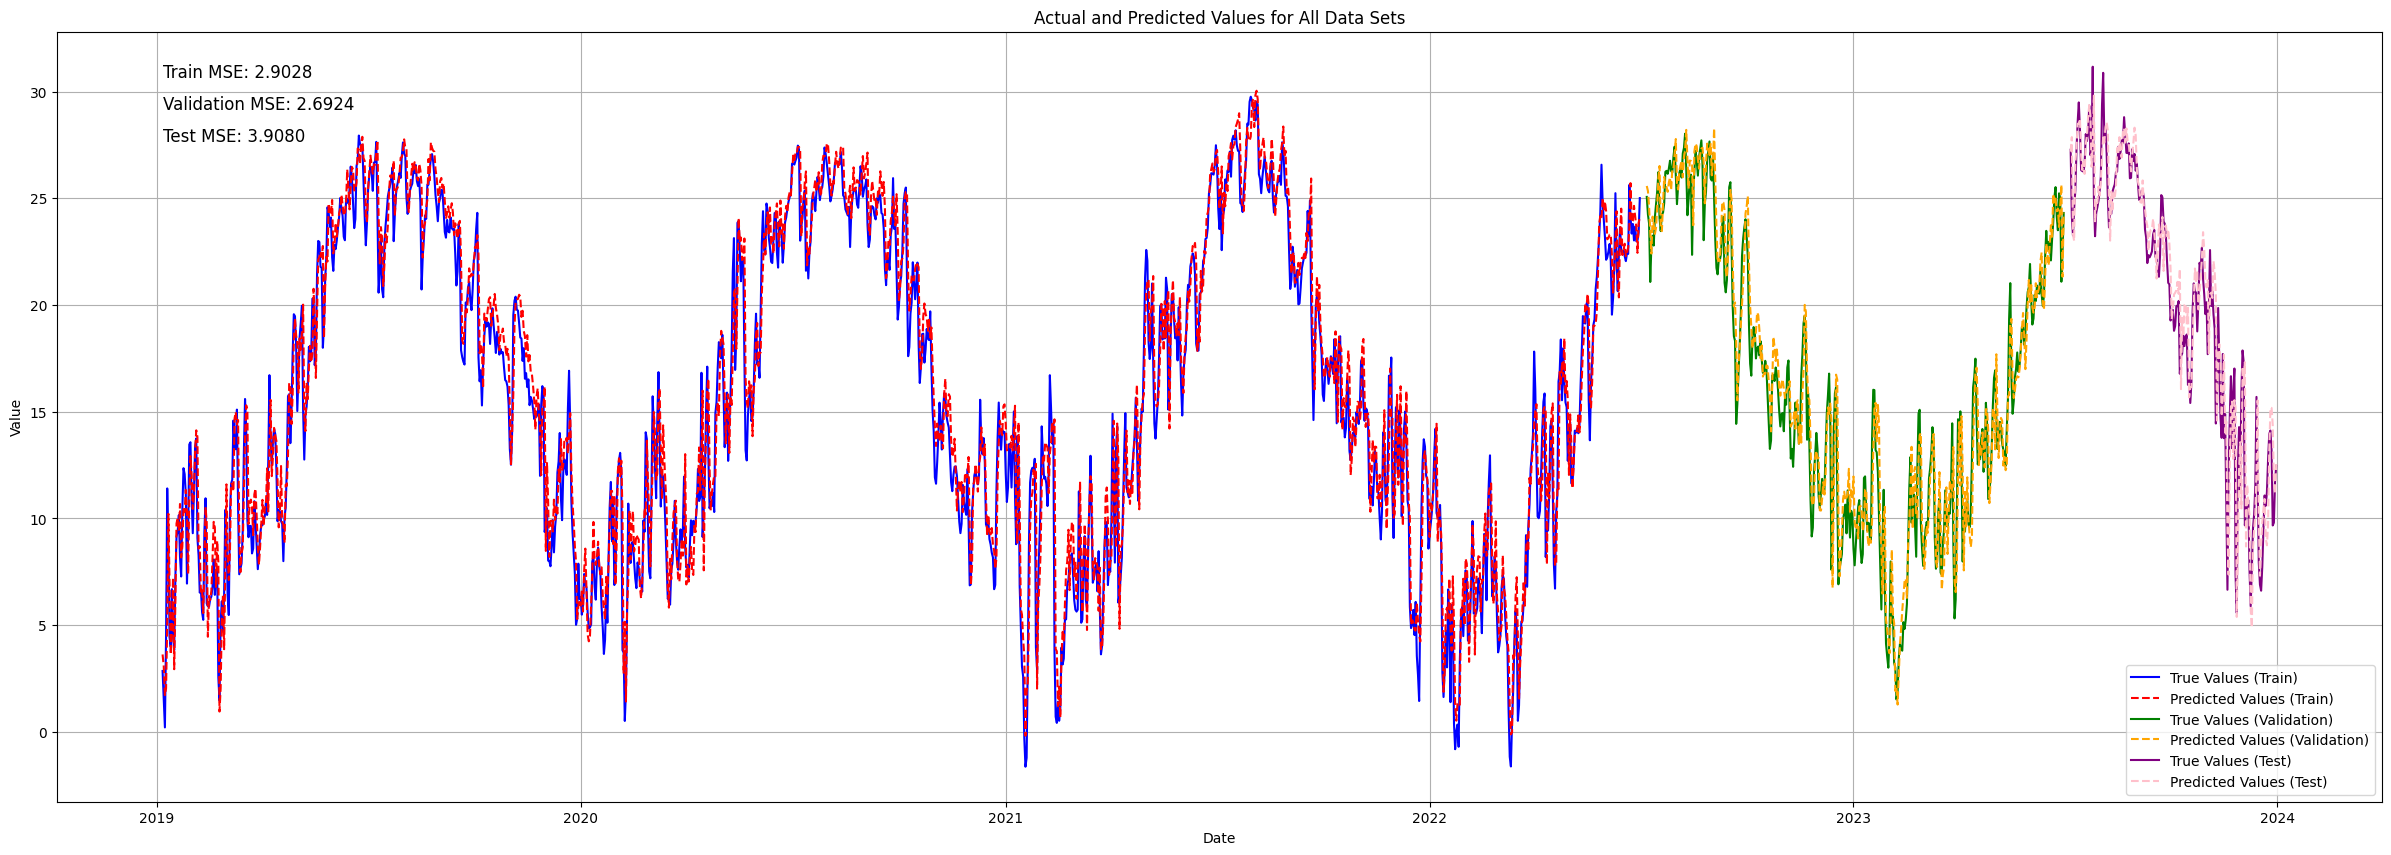

In [27]:
plot_predictions_with_metrics(train_df, val_df, test_df, true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse, time_steps)

# Hyperparameter Optimization

# Task 6: GRU için Hiperparametre arama uzayını hazırlayınız.

- Katman sayısı: 10

- Nöron sayısı: 16'dan 1024'e 32'şer adım. (return_squences bölümünü buna göre ayarlamayı unutmayın)

- Dropout:0.0 - 0.5 arası 0.1 adımlarla.

- Adam için learning rate başlangıc değeri 1e-5, 1e-2 aralığında.

- Dilediğiniz diğer ayarlamaları da yapabilirsiniz.

# Task 6 Solution

In [28]:
input_shape=(X_train.shape[1], X_train.shape[2])

In [29]:
from tensorflow.keras.regularizers import l2

def build_gru_model(hp):
    model = Sequential()
    model.add(Input(shape=input_shape))

    for i in range(hp.Int('num_layers', 1, 10)):
        if i < hp.Int('num_layers', 1, 10) - 1:
            return_seq = True
        else:
            return_seq = False

        model.add(GRU(units=hp.Int('units_' + str(i), min_value=16, max_value=1024, step=32),
                      return_sequences=return_seq,
                      kernel_regularizer=l2(hp.Float('l2_' + str(i), min_value=1e-5, max_value=1e-2, sampling='LOG')),
                      kernel_initializer=hp.Choice('kernel_initializer_' + str(i), values=['glorot_uniform', 'he_uniform', 'random_normal'])
                      ))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float('dropout_' + str(i), min_value=0.0, max_value=0.5, step=0.1)))

    model.add(Dense(1))

    optimizer = Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG'))

    model.compile(optimizer=optimizer,
                  loss='mean_squared_error',
                  metrics=['mse'])

    return model

# Task 7: Random Search Tuner ve Early Stopping yapılarını oluşturarak aramayı başladınız.

# Task 7 Solution

In [30]:
random_search_tuner = RandomSearch(
    build_gru_model,
    objective='val_loss',
    max_trials=20,
    executions_per_trial=1,
    directory='hyperparam_tuning',
    project_name='gru_tuning',
    overwrite=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True)

In [31]:
random_search_tuner.search(X_train, y_train,
                           epochs=500,
                           validation_data=[X_val, y_val],
                           callbacks=[early_stopping])

Trial 20 Complete [00h 03m 30s]
val_loss: 0.004316140431910753

Best val_loss So Far: 0.004316140431910753
Total elapsed time: 01h 39m 48s


# Task 8: Best modeli seçiniz ve performansını değerlendiriniz.

# Task 8 Solution

In [32]:
random_search_tuner.results_summary()

Results summary
Results in hyperparam_tuning/gru_tuning
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 19 summary
Hyperparameters:
num_layers: 2
units_0: 304
l2_0: 9.231838475575431e-05
kernel_initializer_0: glorot_uniform
dropout_0: 0.1
learning_rate: 0.000284909276831134
units_1: 976
l2_1: 0.0011698123057339311
kernel_initializer_1: he_uniform
dropout_1: 0.1
units_2: 464
l2_2: 0.002470685786107889
kernel_initializer_2: glorot_uniform
dropout_2: 0.0
units_3: 240
l2_3: 1.277111942770919e-05
kernel_initializer_3: he_uniform
dropout_3: 0.30000000000000004
units_4: 912
l2_4: 3.0189852702759603e-05
kernel_initializer_4: glorot_uniform
dropout_4: 0.2
units_5: 912
l2_5: 0.003984463250600292
kernel_initializer_5: random_normal
dropout_5: 0.4
units_6: 592
l2_6: 0.0070896054671929455
kernel_initializer_6: glorot_uniform
dropout_6: 0.30000000000000004
units_7: 496
l2_7: 1.1758210361250739e-05
kernel_initializer_7: random_normal
dropout_7: 0.2
units_8: 80
l2_8: 0.001607

In [33]:
best_hps = random_search_tuner.get_best_hyperparameters(num_trials=1)[0]

In [35]:
from joblib import dump

dump(best_hps, 'best_hps_gru.joblib')

['best_hps_gru.joblib']

In [36]:
best_model = random_search_tuner.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [37]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 5, 304)         │       283,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 304)         │         1,216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 304)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 976)            │     3,753,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 976)            │         3,904 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 976)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           977 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,043,425 (15.42 MB)

 Trainable params: 4,040,865 (15.41 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [38]:
train_loss = best_model.evaluate(X_train, y_train, verbose=0)
val_loss = best_model.evaluate(X_val, y_val, verbose=0)
test_loss = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Train Loss: {train_loss[0]}", f"Validation Loss: {val_loss[0]}", f"Test Loss: {test_loss[0]}")

Train Loss: 0.004373100586235523 Validation Loss: 0.004316140431910753 Test Loss: 0.005257494747638702


In [39]:
best_model.save('weather_forecast_gru_tuned.keras')

In [40]:
true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse = evaluate_predictions(best_model, X_train, y_train, X_val, y_val, X_test, y_test, scaler_y)

Train MSE: 3.1365495718567 Validation MSE: 3.0804260335477314 Test MSE: 4.007947955655912


<Figure size 1280x960 with 0 Axes>

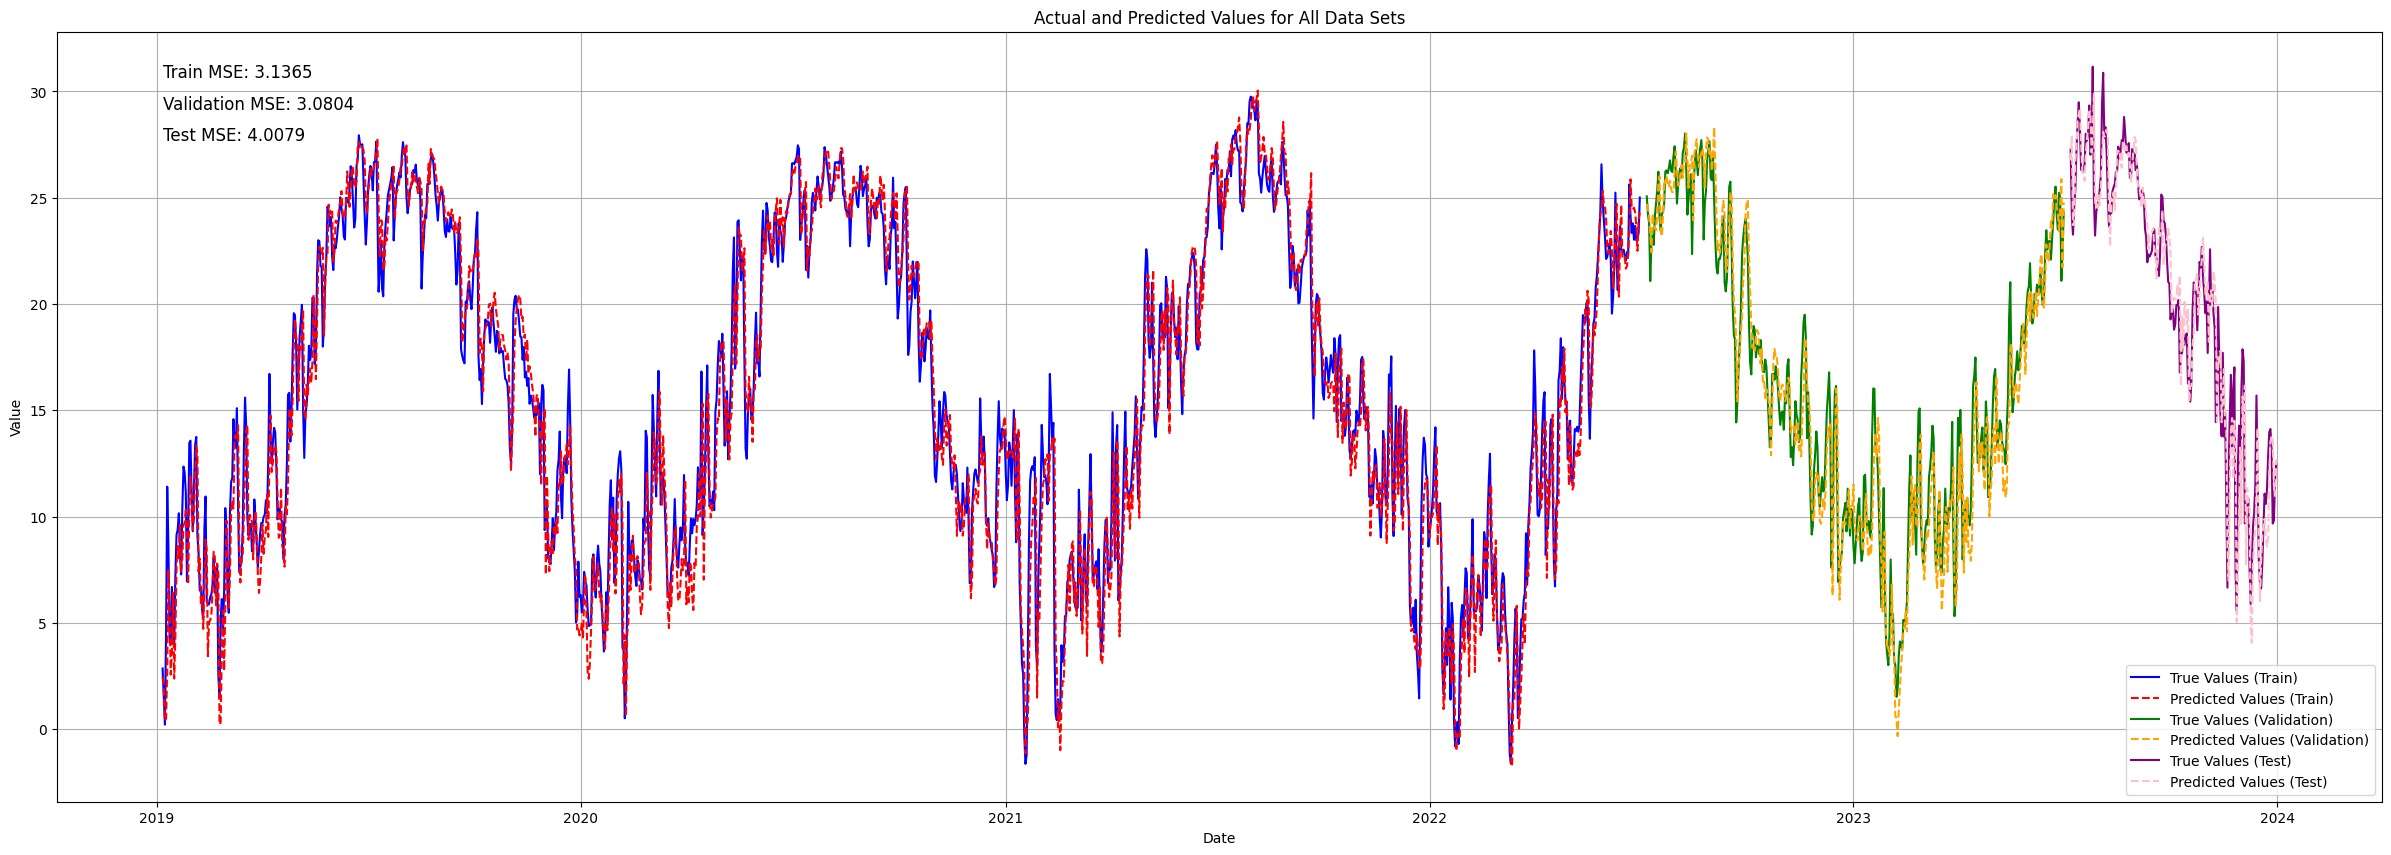

In [41]:
plot_predictions_with_metrics(train_df, val_df, test_df, true_y_train, true_y_train_pred, true_y_val, true_y_val_pred, true_y_test, true_y_test_pred, train_mse, val_mse, test_mse, time_steps)